# Data Understanding – Gutenberg Gait Database

Erste explorative Analyse fürs Data-Understanding-Kapitel.

- Altersverteilung
- Geschlechterverteilung
- Körpergewicht
- GRF-Kurven (V / AP / ML), links und rechts

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = 'GutenbergGaitDatabase/'
OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Kraftkurven laden – links und rechts, alle drei Richtungen
v_left  = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_V_PRO_left.csv'))
ap_left = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_AP_PRO_left.csv'))
ml_left = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_ML_PRO_left.csv'))

v_right  = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_V_PRO_right.csv'))
ap_right = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_AP_PRO_right.csv'))
ml_right = pd.read_csv(os.path.join(DATA_PATH, 'GRF_F_ML_PRO_right.csv'))

# Metadaten nur an die V-Datei mergen, das reicht für Demografie.
# AP/ML haben dieselbe Trial-Struktur, daher gleiche Anzahl Zeilen.
metadata = pd.read_csv(os.path.join(DATA_PATH, 'GRF_metadata.csv'))

merge_cols = [c for c in ['DATASET_ID', 'SUBJECT_ID', 'SESSION_ID']
              if c in v_left.columns and c in metadata.columns]
v_left = v_left.merge(metadata, on=merge_cols, how='left')

print(f'V:  {v_left.shape[0]} Trials')
print(f'AP: {ap_left.shape[0]} Trials')
print(f'ML: {ml_left.shape[0]} Trials')

# eine Zeile pro Person für die Demografie
subj_df = (v_left[['SUBJECT_ID', 'AGE', 'SEX', 'HEIGHT', 'BODY_MASS']]
             .drop_duplicates('SUBJECT_ID')
             .reset_index(drop=True))

print(f'Anzahl eindeutiger Subjekte: {len(subj_df)}')
subj_df.head()

V:  8819 Trials
AP: 8819 Trials
ML: 8819 Trials
Anzahl eindeutiger Subjekte: 350


,SUBJECT_ID,AGE,SEX,HEIGHT,BODY_MASS
0,1,24.0,1.0,184.0,75.4
1,2,21.0,0.0,161.0,55.3
2,3,24.0,0.0,179.0,71.8
3,4,22.0,0.0,170.0,68.4
4,5,28.0,0.0,175.0,72.1


In [2]:
ages   = subj_df['AGE'].dropna()
gender = subj_df['SEX'].dropna()
weight = subj_df['BODY_MASS'].dropna()

print(f'Anzahl Subjekte: {len(subj_df)}')
print(f'Alter: M={ages.mean():.1f}, SD={ages.std():.1f}, '
      f'Min={ages.min():.0f}, Max={ages.max():.0f}')

# Altersgruppen grob zusammengefasst
bins   = [0, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '61+']
print('\nAltersgruppen:')
print(pd.cut(ages, bins=bins, labels=labels,
             include_lowest=True).value_counts().sort_index())

print('\nGeschlecht (n / %):')
for sex, n in gender.value_counts().items():
    print(f'  {sex}: {n} ({n / len(gender) * 100:.1f}%)')

print(f'\nKörpergewicht: M={weight.mean():.1f} kg, SD={weight.std():.1f} kg, '
      f'Min={weight.min():.1f} kg, Max={weight.max():.1f} kg')

Anzahl Subjekte: 350
Alter: M=24.2, SD=7.0, Min=11, Max=64

Altersgruppen:
AGE
18-30    292
31-45     18
46-60      9
61+        1
Name: count, dtype: int64

Geschlecht (n / %):
  1.0: 205 (59.1%)
  0.0: 142 (40.9%)

Körpergewicht: M=70.8 kg, SD=12.0 kg, Min=36.3 kg, Max=110.0 kg


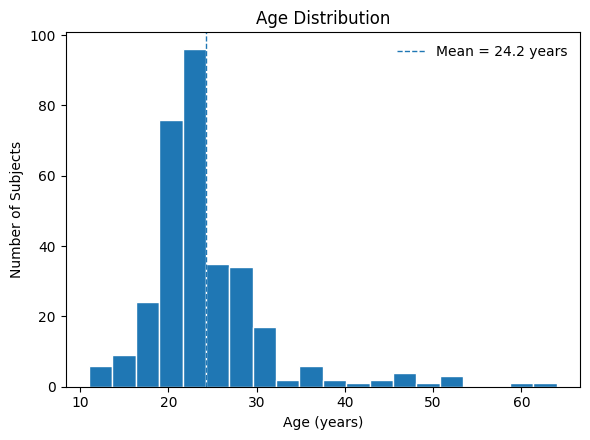

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(ages, bins=20, edgecolor='white')
ax.axvline(ages.mean(), ls='--', lw=1,
           label=f'Mean = {ages.mean():.1f} years')

ax.set_title('Age Distribution')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of Subjects')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'age_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

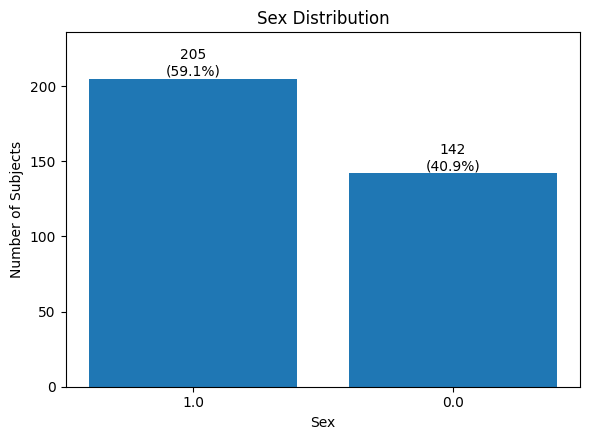

In [4]:
fig, ax = plt.subplots(figsize=(6, 4.5))

counts = gender.value_counts()
pct    = counts / counts.sum() * 100
bars   = ax.bar(counts.index.astype(str), counts.values)

for bar, sex in zip(bars, counts.index):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{counts[sex]}\n({pct[sex]:.1f}%)',
            ha='center', va='bottom')

ax.set_title('Sex Distribution')
ax.set_xlabel('Sex')
ax.set_ylabel('Number of Subjects')
ax.margins(y=0.15)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'sex_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()

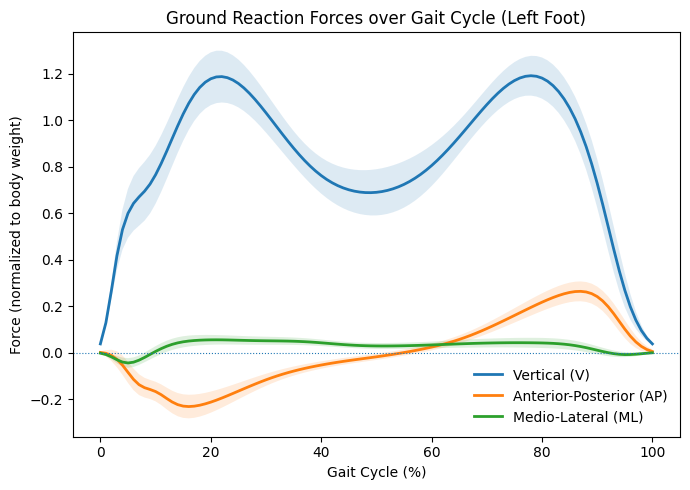

In [5]:
def extract_curve(df, prefix):
    """Mittlere Kurve + SD über alle Trials, x in % Gangzyklus."""
    cols = sorted([c for c in df.columns if c.startswith(prefix)],
                  key=lambda c: int(c.replace(prefix, '')))
    arr  = df[cols].to_numpy(dtype=float)
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    x    = np.linspace(0, 100, len(cols))
    return x, mean, std


# Linker Fuß
fig, ax = plt.subplots(figsize=(7, 5))

curves_left = [
    (v_left,  'F_V_PRO_',  'Vertical (V)'),
    (ap_left, 'F_AP_PRO_', 'Anterior-Posterior (AP)'),
    (ml_left, 'F_ML_PRO_', 'Medio-Lateral (ML)'),
]
for df, prefix, label in curves_left:
    x, m, s = extract_curve(df, prefix)
    ax.plot(x, m, lw=2, label=label)
    ax.fill_between(x, m - s, m + s, alpha=0.15)

ax.axhline(0, lw=0.8, ls=':')
ax.set_title('Ground Reaction Forces over Gait Cycle (Left Foot)')
ax.set_xlabel('Gait Cycle (%)')
ax.set_ylabel('Force (normalized to body weight)')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'grf_left_v_ap_ml.png'),
            dpi=300, bbox_inches='tight')
plt.show()

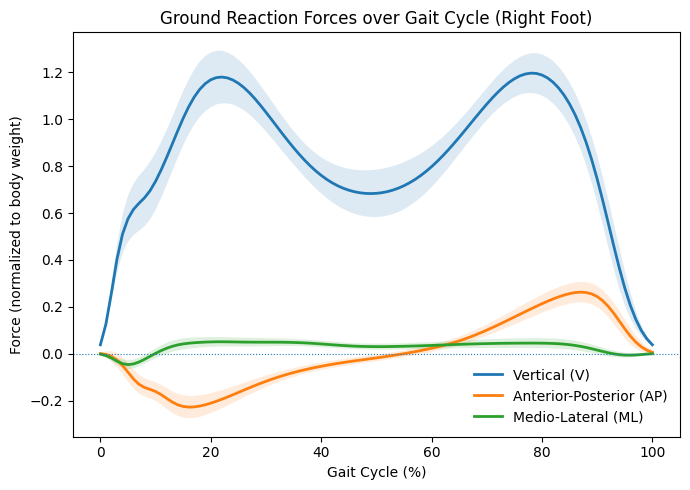

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

curves_right = [
    (v_right,  'F_V_PRO_',  'Vertical (V)'),
    (ap_right, 'F_AP_PRO_', 'Anterior-Posterior (AP)'),
    (ml_right, 'F_ML_PRO_', 'Medio-Lateral (ML)'),
]
for df, prefix, label in curves_right:
    x, m, s = extract_curve(df, prefix)
    ax.plot(x, m, lw=2, label=label)
    ax.fill_between(x, m - s, m + s, alpha=0.15)

ax.axhline(0, lw=0.8, ls=':')
ax.set_title('Ground Reaction Forces over Gait Cycle (Right Foot)')
ax.set_xlabel('Gait Cycle (%)')
ax.set_ylabel('Force (normalized to body weight)')
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'grf_right_v_ap_ml.png'),
            dpi=300, bbox_inches='tight')
plt.show()